In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Daten mit spezifischen Spalten laden
columns_to_use = ['MaxAge', 'YearsCode', 'WorkExp', 'JobSat', 'ConvertedCompYearly']
df = pd.read_csv("survey_results_shortened.csv", usecols=columns_to_use)

df_q98 = (df[df['ConvertedCompYearly'] <= df['ConvertedCompYearly'].quantile(0.98)])


# 2. Fehlende Werte behandeln
df_clean = df_q98.dropna()  # Oder geeignete Imputation

# 3. Daten skalieren
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

In [ ]:
# 1.1 Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1.2 Load and preprocess data
# Assuming df is our cleaned DataFrame
# Select relevant features
features = ['MaxAge', 'YearsCode', 'WorkExp', 'ConvertedCompYearly']
target = 'JobSat'

# 1.3 Group JobSat values into categories
def group_job_satisfaction(score):
    if pd.isna(score):
        return np.nan
    score = float(score)
    if score <= 3:
        return 0
    elif 4 <= score <= 7:
        return 5
    else:  # 8, 9, 10
        return 10

# Apply the grouping function to create a new column
df['JobSat_Grouped'] = df[target].apply(group_job_satisfaction)

# 1.4 Handle missing values
print(f"Missing values in target variable before cleaning: {df['JobSat_Grouped'].isna().sum()}")

# Remove rows where the target is NaN
df_clean = df.dropna(subset=['JobSat_Grouped'])
print(f"Original shape: {df.shape}, Cleaned shape: {df_clean.shape}")

# Update target variable to use the grouped values
X = df_clean[features]
y = df_clean['JobSat_Grouped']

# 1.5 Data splitting
# 70% Training, 15% Validation, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# 1.6 Print class distribution
print("\nClass distribution in the dataset:")
print(y.value_counts().sort_index())

print(f"\nTrainingsdaten: {X_train.shape[0]} Beispiele")
print(f"Validierungsdaten: {X_val.shape[0]} Beispiele")
print(f"Testdaten: {X_test.shape[0]} Beispiele")

# 1.7 Visualize the target distribution
plt.figure(figsize=(10, 5))
y.value_counts().sort_index().plot(kind='bar')
plt.title('Verteilung der Jobzufriedenheit (gruppiert)')
plt.xlabel('Jobzufriedenheit (0=niedrig, 5=mittel, 10=hoch)')
plt.ylabel('Anzahl')
plt.xticks(rotation=0)
plt.show()

Missing values in target variable: 21521
Original shape: (47723, 5), Cleaned shape: (26202, 5)
Trainingsdaten: 18341 Beispiele
Validierungsdaten: 3930 Beispiele
Testdaten: 3931 Beispiele


In [10]:
# 2.1 Numerische und kategoriale Features identifizieren
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 2.2 Preprocessing-Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 2.3 Modell-Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [ ]:
# 3.1 Parameterraum für Grid Search
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__class_weight': ['balanced']

}

# 3.2 Cross-Validation mit StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3.3 Grid Search durchführen
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Starte Grid Search...")
grid_search.fit(X_train, y_train)

# 3.4 Beste Parameter ausgeben
print("\nBeste Parameter gefunden:")
print(grid_search.best_params_)

Starte Grid Search...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Beste Parameter gefunden:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}



Validierungsdaten - Klassifikationsbericht:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        36
         1.0       0.00      0.00      0.00        25
         2.0       0.00      0.00      0.00        65
         3.0       0.00      0.00      0.00       120
         4.0       0.03      0.01      0.01       120
         5.0       0.10      0.04      0.06       280
         6.0       0.12      0.09      0.10       480
         7.0       0.21      0.29      0.25       831
         8.0       0.27      0.43      0.33      1027
         9.0       0.13      0.11      0.12       526
        10.0       0.10      0.06      0.07       420

    accuracy                           0.21      3930
   macro avg       0.09      0.09      0.09      3930
weighted avg       0.17      0.21      0.18      3930



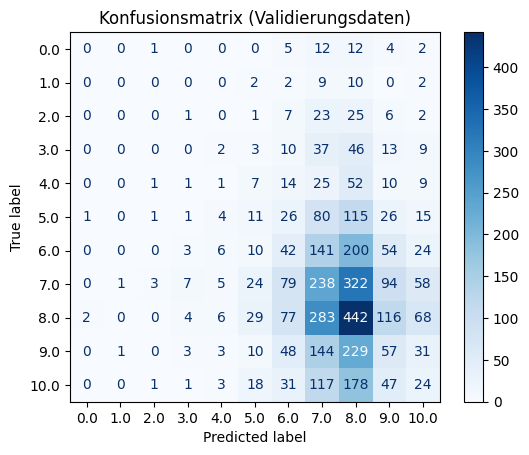

In [12]:
# 4.1 Vorhersagen auf den Validierungsdaten
y_val_pred = grid_search.predict(X_val)

# 4.2 Klassifikationsbericht
print("\nValidierungsdaten - Klassifikationsbericht:")
print(classification_report(y_val, y_val_pred))

# 4.3 Konfusionsmatrix
cm = confusion_matrix(y_val, y_val_pred, labels=grid_search.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=grid_search.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Konfusionsmatrix (Validierungsdaten)')
plt.show()

In [13]:
# 5.1 Bestes Modell aus dem Grid Search
best_model = grid_search.best_estimator_

# 5.2 Vorhersagen auf den Testdaten
y_test_pred = best_model.predict(X_test)

# 5.3 Ausführliche Auswertung
print("\nTestdaten - Detaillierte Auswertung:")
print(classification_report(y_test, y_test_pred))

# 5.4 Wichtigkeit der Features
if hasattr(best_model.named_steps['classifier'], 'feature_importances_'):
    importances = best_model.named_steps['classifier'].feature_importances_
    feature_names = numeric_features.copy()
    
    # Kategoriale Features hinzufügen, falls vorhanden
    if categorical_features:
        ohe = best_model.named_steps['preprocessor'].named_transformers_['cat']
        feature_names.extend(ohe.get_feature_names_out(categorical_features))
    
    # Feature-Wichtigkeiten sortiert ausgeben
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print("\nWichtigste Features:")
    print(feature_importance.head(10))


Testdaten - Detaillierte Auswertung:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        35
         1.0       0.00      0.00      0.00        24
         2.0       0.00      0.00      0.00        65
         3.0       0.04      0.01      0.01       121
         4.0       0.00      0.00      0.00       119
         5.0       0.08      0.03      0.04       281
         6.0       0.16      0.11      0.13       481
         7.0       0.20      0.26      0.23       831
         8.0       0.26      0.42      0.32      1027
         9.0       0.16      0.13      0.14       526
        10.0       0.13      0.08      0.10       421

    accuracy                           0.21      3931
   macro avg       0.09      0.09      0.09      3931
weighted avg       0.17      0.21      0.18      3931


Wichtigste Features:
               feature  importance
3  ConvertedCompYearly    0.467748
1            YearsCode    0.248872
2              WorkExp

In [14]:
# 6.1 Metriken extrahieren
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_test_pred, average='weighted')
recall = recall_score(y_test, y_test_pred, average='weighted')
f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\nZusammenfassung der Metriken (gewichteter Durchschnitt):")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# 6.2 Bewertung der Ergebnisse
print("""
Bewertung der Ergebnisse:
1. Precision vs. Recall:
   - Hohe Precision: Weniger False Positives (wichtig, wenn die Kosten für falsche Alarme hoch sind)
   - Hoher Recall: Weniger False Negatives (wichtig, wenn alle positiven Fälle gefunden werden müssen)

2. F1-Score:
   - Harmonisches Mittel aus Precision und Recall
   - Besonders nützlich bei unausgeglichenen Klassen

3. Praxisrelevanz:
   - Die gewählten Metriken sollten sich an der konkreten Anwendung orientieren
   - Bei ungleichen Klassenverteilungen ist der gewichtete Durchschnitt oft aussagekräftiger
   - Die Konfusionsmatrix gibt Aufschluss über die Verteilung der Fehlklassifikationen
""")


Zusammenfassung der Metriken (gewichteter Durchschnitt):
Precision: 0.1720
Recall: 0.2071
F1-Score: 0.1813

Bewertung der Ergebnisse:
1. Precision vs. Recall:
   - Hohe Precision: Weniger False Positives (wichtig, wenn die Kosten für falsche Alarme hoch sind)
   - Hoher Recall: Weniger False Negatives (wichtig, wenn alle positiven Fälle gefunden werden müssen)

2. F1-Score:
   - Harmonisches Mittel aus Precision und Recall
   - Besonders nützlich bei unausgeglichenen Klassen

3. Praxisrelevanz:
   - Die gewählten Metriken sollten sich an der konkreten Anwendung orientieren
   - Bei ungleichen Klassenverteilungen ist der gewichtete Durchschnitt oft aussagekräftiger
   - Die Konfusionsmatrix gibt Aufschluss über die Verteilung der Fehlklassifikationen



## Begründung für Random Forest statt SVM

- Random Forest ist robuster gegenüber Ausreißern, schiefen Verteilungen und unvollständigen Survey-Daten.  
- Das Modell skaliert besser bei großen Datensätzen und vielen Features als eine SVM.  
- Es benötigt weniger Datenvorverarbeitung und ist einfacher zu optimieren.    
- Zudem liefert Random Forest verständliche Feature-Wichtigkeiten und ist dadurch deutlich besser interpretierbar.
